# 06 - Spatial Filter and Threshold Diagnostics

The previous notebooks produced a valid FIRMS + NDVI dataset, but the rectangular grid contains many low-information cells: ocean, no-data cells, and very low-vegetation desert cells. This notebook creates a simple NDVI-based modeling mask, saves a filtered dataset, retrains a filtered Random Forest baseline, and analyzes probability thresholds.

Do not use accuracy alone for this project. The positive class is rare, so precision, recall, F1, ROC AUC, PR AUC, and the number of alerts are more informative.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Edit this path to the location where you uploaded the project folder in Google Drive.
PROJECT_DIR = "/content/drive/MyDrive/fire-risk-project"
PROJECT_DIR = Path(PROJECT_DIR)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = OUTPUTS_DIR / "reports"

for path in [PROCESSED_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

GRID_PATH = PROCESSED_DIR / "morocco_ws_grid.geojson"
NDVI_GRID_PATH = PROCESSED_DIR / "ndvi_grid_2023.csv"
DATASET_PATH = PROCESSED_DIR / "fire_risk_dataset_2023_ndvi_firms.csv"

CELL_QUALITY_PATH = PROCESSED_DIR / "grid_cell_quality_2023.csv"
MODELING_GRID_IDS_PATH = PROCESSED_DIR / "modeling_grid_ids_ndvi_filter_2023.csv"
FILTERED_DATASET_PATH = PROCESSED_DIR / "fire_risk_dataset_2023_filtered.csv"
FILTERED_MODEL_PATH = MODELS_DIR / "random_forest_fire_risk_2023_filtered.joblib"
FILTERED_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023_filtered_rf.csv"
THRESHOLD_METRICS_PATH = REPORTS_DIR / "threshold_metrics_random_forest_2023_filtered.csv"
FILTER_MAP_PATH = FIGURES_DIR / "modeling_grid_filter_2023.png"
THRESHOLD_PLOT_PATH = FIGURES_DIR / "threshold_precision_recall_filtered_rf.png"


Mounted at /content/drive


In [2]:
import joblib
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
)


## Load Processed Inputs

This notebook assumes notebooks `02`, `03`, and `04` were already run in Colab. It does not download data.


In [3]:
grid = gpd.read_file(GRID_PATH)
grid["grid_id"] = grid["grid_id"].astype(int)

ndvi_grid = pd.read_csv(NDVI_GRID_PATH)
ndvi_grid["date"] = pd.to_datetime(ndvi_grid["date"])
ndvi_grid["grid_id"] = ndvi_grid["grid_id"].astype(int)

dataset = pd.read_csv(DATASET_PATH)
dataset["date"] = pd.to_datetime(dataset["date"])
dataset["grid_id"] = dataset["grid_id"].astype(int)

print("grid:", grid.shape)
print("ndvi_grid:", ndvi_grid.shape)
print("dataset:", dataset.shape)
print("dataset positive rate:")
print(dataset["fire_risk_label"].value_counts(normalize=True, dropna=False))


grid: (4095, 6)
ndvi_grid: (98280, 4)
dataset: (1000060, 14)
dataset positive rate:
fire_risk_label
0    0.989867
1    0.010133
Name: proportion, dtype: float64


## Build A Simple Modeling Mask

The filter below keeps cells with enough valid NDVI observations and at least minimal vegetation. These thresholds are intentionally simple and should be reported as a modeling choice.


In [4]:
MIN_VALID_FRACTION = 0.50
MIN_MEDIAN_NDVI = 0.05

cell_quality = (
    ndvi_grid.groupby("grid_id")["ndvi"]
    .agg(
        ndvi_total_obs="size",
        ndvi_valid_obs="count",
        ndvi_mean="mean",
        ndvi_median="median",
        ndvi_min="min",
        ndvi_max="max",
    )
    .reset_index()
)
cell_quality["ndvi_valid_fraction"] = cell_quality["ndvi_valid_obs"] / cell_quality["ndvi_total_obs"]

fire_by_cell = dataset.groupby("grid_id")["fire_count"].sum().reset_index(name="fire_count_2023")
cell_quality = cell_quality.merge(fire_by_cell, on="grid_id", how="left")
cell_quality["fire_count_2023"] = cell_quality["fire_count_2023"].fillna(0).astype(int)

cell_quality["keep_for_modeling"] = (
    (cell_quality["ndvi_valid_fraction"] >= MIN_VALID_FRACTION)
    & (cell_quality["ndvi_median"] >= MIN_MEDIAN_NDVI)
)

cell_quality.to_csv(CELL_QUALITY_PATH, index=False)
modeling_grid_ids = cell_quality.loc[cell_quality["keep_for_modeling"], ["grid_id"]].copy()
modeling_grid_ids.to_csv(MODELING_GRID_IDS_PATH, index=False)

print("Total grid cells:", len(cell_quality))
print("Kept grid cells:", len(modeling_grid_ids))
print("Removed grid cells:", len(cell_quality) - len(modeling_grid_ids))
print("Saved:", CELL_QUALITY_PATH)
print("Saved:", MODELING_GRID_IDS_PATH)
display(cell_quality.describe(include="all"))


Total grid cells: 4095
Kept grid cells: 2787
Removed grid cells: 1308
Saved: /content/drive/MyDrive/fire-risk-project/data/processed/grid_cell_quality_2023.csv
Saved: /content/drive/MyDrive/fire-risk-project/data/processed/modeling_grid_ids_ndvi_filter_2023.csv


,grid_id,ndvi_total_obs,ndvi_valid_obs,ndvi_mean,ndvi_median,ndvi_min,ndvi_max,ndvi_valid_fraction,fire_count_2023,keep_for_modeling
count,4095.000000,4095.0,4095.000000,2794.000000,2794.000000,2794.000000,2794.000000,4095.000000,4095.000000,4095
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2787
mean,2047.000000,24.0,16.358486,0.126767,0.123735,0.109258,0.151445,0.681604,1.093773,NaN
std,1182.269005,0.0,11.176622,0.077145,0.071631,0.053918,0.125186,0.465693,13.533363,NaN
min,0.000000,24.0,0.000000,-0.022472,-0.018733,-0.171800,0.050420,0.000000,0.000000,NaN
25%,1023.500000,24.0,0.000000,0.092538,0.092446,0.084881,0.099000,0.000000,0.000000,NaN
50%,2047.000000,24.0,24.000000,0.104164,0.103787,0.096499,0.110811,1.000000,0.000000,NaN
75%,3070.500000,24.0,24.000000,0.120208,0.119957,0.111048,0.127640,1.000000,0.000000,NaN


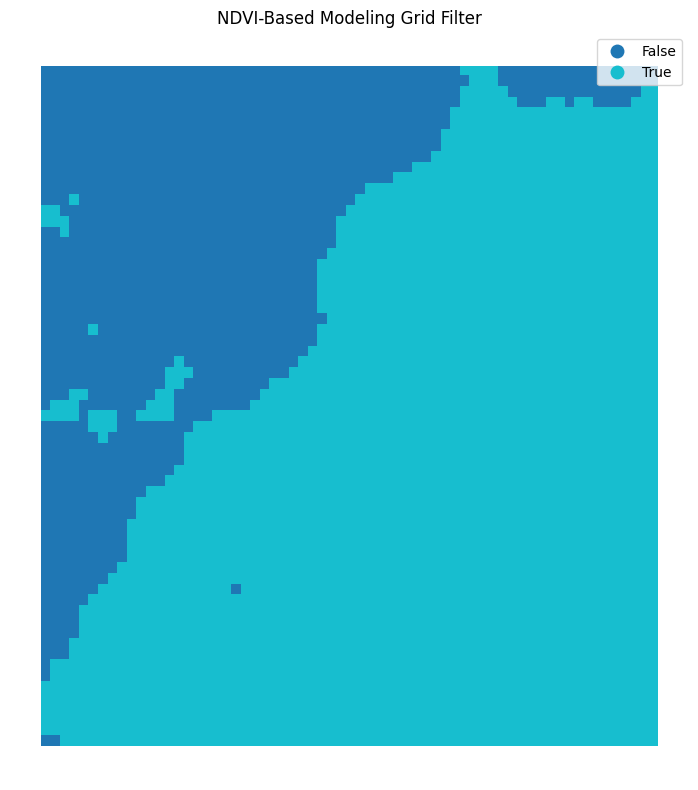

Saved: /content/drive/MyDrive/fire-risk-project/outputs/figures/modeling_grid_filter_2023.png


In [5]:
grid_quality = grid.merge(cell_quality, on="grid_id", how="left")

fig, ax = plt.subplots(figsize=(8, 8))
grid_quality.plot(
    column="keep_for_modeling",
    categorical=True,
    legend=True,
    linewidth=0.05,
    edgecolor="none",
    ax=ax,
)
ax.set_title("NDVI-Based Modeling Grid Filter")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FILTER_MAP_PATH, dpi=180)
plt.show()
print("Saved:", FILTER_MAP_PATH)


## Save Filtered Dataset

The filtered dataset should be used for the next baseline and temporal models. This avoids letting huge no-data or nearly non-burnable areas dominate the evaluation.


In [7]:
keep_ids = set(modeling_grid_ids["grid_id"])
filtered = dataset[dataset["grid_id"].isin(keep_ids)].copy()
filtered.to_csv(FILTERED_DATASET_PATH, index=False)

print("Original rows:", len(dataset))
print("Filtered rows:", len(filtered))
print("Original positive rate:")
print(dataset["fire_risk_label"].value_counts(normalize=True))
print("Filtered positive rate:")
print(filtered["fire_risk_label"].value_counts(normalize=True))
print("Saved:", FILTERED_DATASET_PATH)


Original rows: 1000060
Filtered rows: 997746
Original positive rate:
fire_risk_label
0    0.989867
1    0.010133
Name: proportion, dtype: float64
Filtered positive rate:
fire_risk_label
0    0.989843
1    0.010157
Name: proportion, dtype: float64
Saved: /content/drive/MyDrive/fire-risk-project/data/processed/fire_risk_dataset_2023_filtered.csv


## Retrain Filtered Random Forest

This gives a cleaner baseline after removing weak grid cells. Compare this against notebook `04`, then use the filtered dataset in notebook `07`.


In [8]:
FEATURES = [
    "ndvi",
    "ndvi_change_16d",
    "month",
    "dayofyear",
    "fire_count_lag_1d",
    "fire_count_past_7d",
    "fire_count_past_30d",
]
TARGET = "fire_risk_label"

model_df = filtered.dropna(subset=FEATURES + [TARGET]).copy()
train_df = model_df[model_df["date"] < pd.Timestamp("2023-10-01")].copy()
test_df = model_df[model_df["date"] >= pd.Timestamp("2023-10-01")].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)
X_test = test_df[FEATURES]
y_test = test_df[TARGET].astype(int)

print("Filtered train rows:", len(train_df))
print("Filtered test rows:", len(test_df))
print("Train class counts:")
print(y_train.value_counts())
print("Test class counts:")
print(y_test.value_counts())

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

classes = list(rf.classes_)
positive_index = classes.index(1)
test_proba = rf.predict_proba(X_test)[:, positive_index]
test_pred = (test_proba >= 0.5).astype(int)

print(classification_report(y_test, test_pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred, labels=[0, 1]))
if y_test.nunique() == 2:
    print("ROC AUC:", roc_auc_score(y_test, test_proba))
    print("PR AUC:", average_precision_score(y_test, test_proba))

joblib.dump(rf, FILTERED_MODEL_PATH)
print("Saved:", FILTERED_MODEL_PATH)


Filtered train rows: 760851
Filtered test rows: 236895
Train class counts:
fire_risk_label
0    753159
1      7692
Name: count, dtype: int64
Test class counts:
fire_risk_label
0    234453
1      2442
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    234453
           1       0.09      0.71      0.15      2442

    accuracy                           0.92    236895
   macro avg       0.54      0.82      0.56    236895
weighted avg       0.99      0.92      0.95    236895

Confusion matrix:
[[216043  18410]
 [   700   1742]]
ROC AUC: 0.9185220238693643
PR AUC: 0.21393763810536293
Saved: /content/drive/MyDrive/fire-risk-project/outputs/models/random_forest_fire_risk_2023_filtered.joblib


In [9]:
predictions = test_df[["grid_id", "date", "fire_count", "fire_next_7d_count", "fire_risk_label"]].copy()
predictions["pred_probability"] = test_proba
predictions["pred_label_050"] = test_pred
predictions.to_csv(FILTERED_PREDICTIONS_PATH, index=False)
print("Saved:", FILTERED_PREDICTIONS_PATH)
display(predictions.head())


Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023_filtered_rf.csv


,grid_id,date,fire_count,fire_next_7d_count,fire_risk_label,pred_probability,pred_label_050
273,2,2023-10-01,0,0.0,0,0.007409,0
274,2,2023-10-02,0,0.0,0,0.007409,0
275,2,2023-10-03,0,0.0,0,0.007409,0
276,2,2023-10-04,0,0.0,0,0.007409,0
277,2,2023-10-05,0,0.0,0,0.007409,0


## Threshold Diagnostics

The default `0.5` threshold is rarely optimal for rare-event fire risk. Use this table to choose an operating point based on the purpose of the system.


In [10]:
thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
rows = []
for threshold in thresholds:
    pred = (test_proba >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        pred,
        labels=[1],
        average="binary",
        zero_division=0,
    )
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "alerts": int(tp + fp),
            "missed_positive": int(fn),
        }
    )

threshold_metrics = pd.DataFrame(rows)
threshold_metrics.to_csv(THRESHOLD_METRICS_PATH, index=False)
print("Saved:", THRESHOLD_METRICS_PATH)
display(threshold_metrics)

best_f1_row = threshold_metrics.loc[threshold_metrics["f1"].idxmax()]
print("Best F1 threshold:")
print(best_f1_row)


Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/threshold_metrics_random_forest_2023_filtered.csv


,threshold,precision,recall,f1,tp,fp,tn,fn,alerts,missed_positive
0,0.05,0.027858,0.952088,0.054131,2325,81135,153318,117,83460,117
1,0.10,0.043068,0.924242,0.082302,2257,50148,184305,185,52405,185
2,0.15,0.066832,0.895577,0.124382,2187,30537,203916,255,32724,255
3,0.20,0.072204,0.871007,0.133354,2127,27331,207122,315,29458,315
4,0.25,0.078584,0.813677,0.143326,1987,23298,211155,455,25285,455
5,0.30,0.082098,0.802621,0.148959,1960,21914,212539,482,23874,482
6,0.35,0.081769,0.769042,0.147822,1878,21089,213364,564,22967,564
7,0.40,0.081770,0.737101,0.147209,1800,20213,214240,642,22013,642
8,0.45,0.083726,0.721130,0.150032,1761,19272,215181,681,21033,681
9,0.50,0.086443,0.713350,0.154200,1742,18410,216043,700,20152,700


Best F1 threshold:
threshold               0.800000
precision               0.277778
recall                  0.262080
f1                      0.269701
tp                    640.000000
fp                   1664.000000
tn                 232789.000000
fn                   1802.000000
alerts               2304.000000
missed_positive      1802.000000
Name: 15, dtype: float64


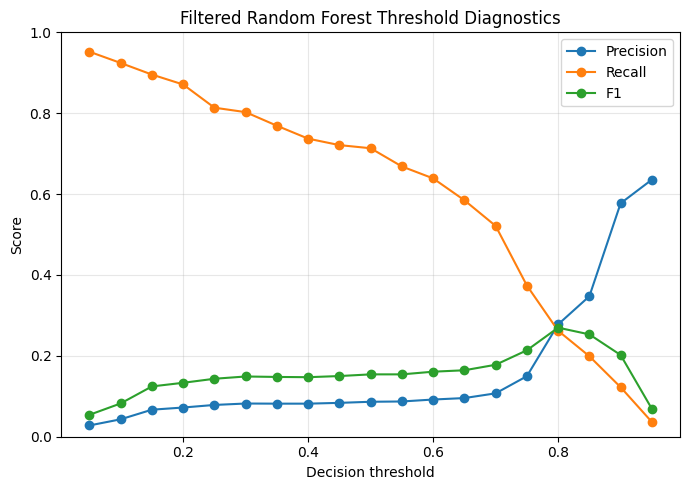

Saved: /content/drive/MyDrive/fire-risk-project/outputs/figures/threshold_precision_recall_filtered_rf.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(threshold_metrics["threshold"], threshold_metrics["precision"], marker="o", label="Precision")
ax.plot(threshold_metrics["threshold"], threshold_metrics["recall"], marker="o", label="Recall")
ax.plot(threshold_metrics["threshold"], threshold_metrics["f1"], marker="o", label="F1")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Filtered Random Forest Threshold Diagnostics")
fig.tight_layout()
fig.savefig(THRESHOLD_PLOT_PATH, dpi=180)
plt.show()
print("Saved:", THRESHOLD_PLOT_PATH)


## Interpretation Checklist

- If precision improves after filtering while recall stays acceptable, use the filtered dataset for temporal modeling.
- If precision is still very low, the model needs stronger predictors, especially weather, drought, land cover, and topography.
- If most false positives are concentrated in a few grid cells, inspect those locations. They may represent persistent thermal sources, agricultural burning, or areas where the target definition is too noisy.
- If recall is low, use a lower threshold for early-warning maps, but report the increase in false alerts.
